# Tutorial-01: 基于 ASF API, 如何查询 OPERA Sentinel-1 RTC 产品数据

> ottoKae - Jan 15, 2026 / last update on Jan 31, 2026

---

## 🧭 1/8 教程目标: 理解并使用 `asf_search`

欢迎来到本教程。本教程旨在演示如何使用 [ASF Search API](https://github.com/asfadmin/Discovery-asf_search) 和 Python 查询 NASA OPERA 项目生产的 Sentinel-1 RTC（Radiometrically Terrain Corrected）产品。说白话就是**给你一个NASA卫星资产的全信息检索方式，包括下载链接，预览图，成像信息等等**

- 使用 WKT（Well-Known Text）格式定义空间查询区域；
- 设置时间、轨道方向、平台、计划方式、等过滤条；
- 获取影像文件的下载链接和元数据信息（如产品名称、时间、极化方式、下载链接等）；
- 支持进一步处理如图像下载、批量批处理等任务；

该代码适用于构建自己的 Sentinel-1 数据快捷查询，可进一步理解"时序数据下载与预处理 `s1grits`"（Tutorial-02）。

---

## 🛠️ 2/8 环境准备

在开始编写代码之前，需要确保 Python 环境中安装了必要的库。本教程核心依赖 `asf_search`。

- **请使用conda**：由于 `asf_search` 库要求 `Python 3.12+` 环境，且其依赖的地理空间底层库（如 `shapely`, `geopandas`, `gdal`）涉及复杂的 C/C++ 二进制编译，直接使用 `pip` 安装极易引发依赖冲突（Dependency Hell）。因此，**强烈建议使用 Conda 创建独立的虚拟环境**。（尽量只用 `conda-forge` 一个主渠道；另外，GIS 环境不要混 `pip` 安装核心二进制依赖，特别是 `gdal`，使用 `conda install geopandas`，会默认安装 `gdal` 等核心依赖）

- **请使用 libmamba 求解器**：另外，在处理包含 `conda-forge` 这样庞大软件仓库的 GIS 环境（如 `leafmap`, `geopandas`）时，`Conda` 传统的默认求解器（Classic Solver）因算法效率问题，极易陷入死循环或卡死。为了确保快速且成功地构建环境，请务必使用 `libmamba` 求解器。（`Conda` 只需要将求解器 `solver` 切换到 `libmamba`，即可使用，保持 `conda` 工作流不变；如果 `conda` + `libmamba` 仍然不稳定，可考虑使用 `mamba` ）

- 快速部署：请确保您已下载本项目提供的 `environment.yml` 文件，然后在终端中依次运行以下命令：

1. 启用 Libmamba 求解器支持 首先在 base 环境中安装求解器插件：

```!conda install -n base conda-libmamba-solver```

2. 基于配置文件创建环境 使用 libmamba 加速解析，一键安装 Python 3.12 及所有依赖：

```!conda env create -f environment.yml --solver=libmamba```

3. 激活环境

```!conda activate py312_s1grits```

5. 关联Kernel，登录 Jupyter Notebook（Optional）

```python -m ipykernel install --user --name py312_s1grits --display-name "Python3 (py312_s1grits)"```

```jupyter notebook```

---

## 🛰️ 3/8 asf 简介

ASF（Alaska Satellite Facility） 是美国阿拉斯加大学费尔班克斯分校运营的 NASA 合作数据中心，专注于合成孔径雷达（SAR）数据的存储、分发与研究支持。ASF 是全球主要的开源雷达遥感数据分发平台之一，致力于为科学家、工程师和公众提供高质量、标准化的 SAR 数据产品与 API 工具。ASF 的核心服务包括：

- 数据托管：提供如 Sentinel-1、ALOS PALSAR、RADARSAT、SMAP 等卫星的 SAR 数据产品，包括 Level-0、GRD、SLC、RTC 等处理级别；
- 数据检索 API：提供 Python 接口 asf_search，和 Web 门户 https://search.asf.alaska.edu；
- 支持 OPERA 项目：ASF 是 OPERA 项目核心合作方，协助分发其 RTC 产品等分析就绪数据；
- 云端访问：ASF 数据已全面迁移至 Amazon Web Services（AWS）云端托管（NASA Earthdata Cloud），支持云端处理；**OPERA数据中默认存有ASW S3地址，这是进行云端流式传输下载的核心。**

---

## 🌍 4/8 OPERA Sentinel-1 RTC 简介

**OPERA（Observational Products for End-users from Remote-sensing Analysis）** 是由 NASA 主导的地球观测数据产品处理项目，其目标是利用现有卫星数据（如 Sentinel-1、Landsat、Sentinel-2）生成高质量、标准化的下游分析就绪数据产品（ARD）。

在本教程中，我们使用 OPERA 生成的 Sentinel-1 **RTC 产品（地形辐射校正）**，其具有：

- 分析就绪：直接提供后向散射系数 ($\gamma^0$)，已消除地形起伏带来的辐射偏差；
- 几何精准：基于高精度 DEM 校正，消除透视收缩与叠掩，严格配准至 UTM 投影；
- 标准统一：提供 30米 标准空间分辨率，覆盖近全球；
- 时序稳定：基于 Burst (突发模式) 帧进行封装，保证了时间序列在空间上的严格同步与对齐。

---

## 🗺️ 5/8 WKT 格式说明（定义查询区域）

WKT（Well-Known Text）是地理信息系统中用于描述几何对象（点、线、面等）的标准格式。

**WKT可从 ASF Web 门户 https://search.asf.alaska.edu 右上角选项中快速获取**

在此处，我们为武汉大学划定一个矩形多边形（WKT格式），定义为感兴趣区域（ROI）：

```POLYGON((114.3355 30.5214,114.3823 30.5214,114.3823 30.5583,114.3355 30.5583,114.3355 30.5214))```

In [1]:
import asf_search as asf
from pprint import pprint

# 1. 定义查询区域（ROI）
# 使用 WKT 格式描述一个矩形多边形（注意：坐标顺序通常为 经度 纬度）
test_wkt = "POLYGON((114.3355 30.5214,114.3823 30.5214,114.3823 30.5583,114.3355 30.5583,114.3355 30.5214))"

print(f"正在检索区域的历史存档数据: {test_wkt[:50]}...")

# 2. 发起 ASF 查询
# 注意：OPERA RTC 数据检索时，参数设置需精准
try:
    resp = asf.search(
        intersectsWith=test_wkt,                     # 交叉区域：指定的 WKT ROI
        platform=[asf.PLATFORM.SENTINEL1],           # 卫星平台：Sentinel-1
        processingLevel='RTC',                       # 产品级别：必须指定为 'RTC' 以锁定 OPERA 产品
        start="2025-01-01T00:00:00Z",                # 起始时间 (UTC)
        end="2025-12-31T23:59:59Z",                  # 结束时间 (UTC)
        maxResults=1000,                             # 最大返回数量限制
        flightDirection="ASCENDING"                  # 轨道方向：'ASCENDING'(升轨) 或 'DESCENDING'(降轨)
    )
    
    # 3. 打印结果概览
    print(f"\n 查询成功！共找到 {len(resp)} 景影像。")

    # 4. 结果解析样例
    if len(resp) > 0:
        item = resp[0] # 取第一条记录作为样例
        props = item.properties
        
        print("\n=== 样例数据核心元数据 ===")
        print(f"Filename (文件名):    {props.get('sceneName')}")
        print(f"File ID (唯一标识):   {props.get('fileID')}")
        print(f"Acquisition (时间):   {props.get('startTime')}")
        print(f"Level (处理级别):     {props.get('processingLevel')}")
        print(f"Polarization (极化):  {props.get('polarization')}")
        print(f"Orbit (轨道方向):     {props.get('flightDirection')}")
        print(f"AWS S3 (云端下载):    {props.get('s3Urls')}")
        
        # 检查附加链接 (OPERA 的 TIF 文件通常在这里)
        tif_files = [u for u in props.get('additionalUrls', []) if u.endswith('.tif')]
        print(f"GeoTIFFs (包含波段):  {len(tif_files)} 个文件")

    else:
        print("未找到符合条件的产品。")
        print("提示：请尝试检查 WKT。")

except asf.ASFSearchError as e:
    print(f"搜索发生错误: {e}")

正在检索区域的历史存档数据: POLYGON((114.3355 30.5214,114.3823 30.5214,114.382...

 查询成功！共找到 91 景影像。

=== 样例数据核心元数据 ===
Filename (文件名):    OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0
File ID (唯一标识):   OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0
Acquisition (时间):   2025-12-26T10:27:57Z
Level (处理级别):     RTC
Polarization (极化):  ['VV', 'VH']
Orbit (轨道方向):     ASCENDING
AWS S3 (云端下载):    ['s3://asf-cumulus-prod-opera-browse/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0_BROWSE.png', 's3://asf-cumulus-prod-opera-browse/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0_BROWSE.png.md5', 's3://asf-cumulus-prod-opera-browse/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T1

---
## 🖼️ 6/9 预览图可视化

asf_search 的一大优势在于不仅返回产品的S3下载链接，还提供了丰富的元数据。在成功检索 OPERA RTC 产品信息后，我们可以进一步自定义函数调用元数据。

这些元数据中最直观实用的一项，便是预览图的URL，它可以帮助我们在下载完整产品前，快速预览感兴趣区域的图像质量和影像特征。

这部分，我们直接提取 browse 字段（预览图 URL），即时渲染影像快照，以便快速确认数据质量。
ASF 平台为每个 OPERA 产品提供 三种分辨率 的图像快视图：
- standard：标准分辨率（适合质量评估与展示）
- low-res：低分辨率（加载速度快，适合低带宽预览）
- thumbnail：缩略图（适用于嵌入小图标或概览）

自定义函数 `get_rtc_browse(item)` 来下载并显示其预览图像（Browse Image）。该函数封装于项目目录 `s1grits/asf_viewer.py` 中，并基于 sceneName 自动命名和保存图像到 `output/` 文件夹。以下代码片段将获取并展示检索结果对应的预览图。
- 自动提取 browse 字段中符合指定分辨率的 URL
- 下载并读取图像内容，解析为 PIL.Image 对象
- 按照产品 sceneName 自动命名保存，格式"../output/browser_{sceneName}_{browse_type}.png"

[INFO] Successfully saved low-res browse image:
       D:\Project\claude-demo\S1-GRiTS-core\notebooks\tmp\browser_OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0_low-res.png
[INFO] Image size: (1024, 529), Format: PNG


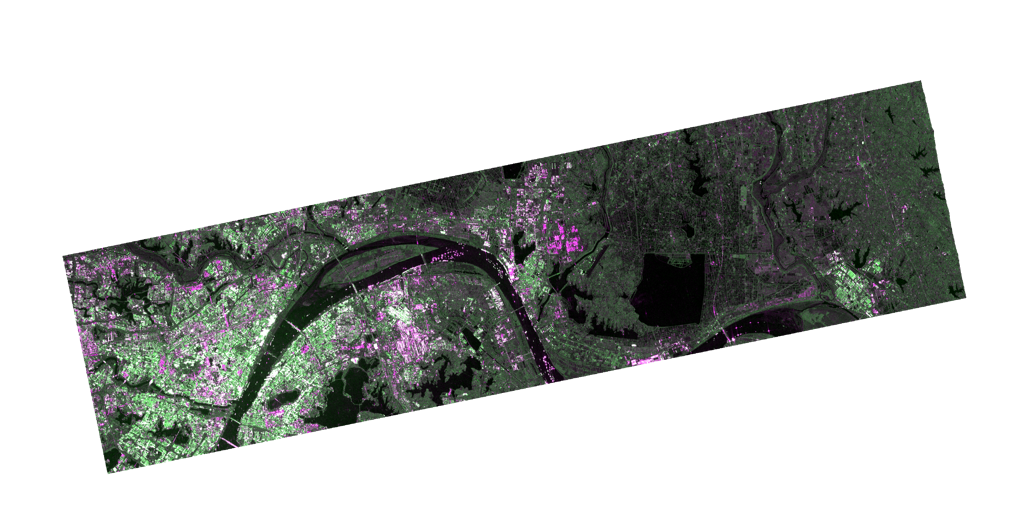

In [2]:
import os
import sys
from IPython.display import display
from s1grits.asf_viewer import get_rtc_browse

current_dir = os.getcwd() # 获取当前 notebook 的目录
tmp_dir = os.path.join(current_dir, "tmp")   

img = get_rtc_browse(item, browse_type = 'low-res', save_dir=tmp_dir) # browse_type: 标准图像'standard', 低分辨率图像'low-res', and 缩略图'thumbnail'
display(img)

## 📚 7/9 探索元数据：构建自动化管道的基石

`asf_search` 返回的每一个结果对象，都包含一个名为 `properties` 的字典。这是我们**实现产品自由下载和定制化处理的基础**。

`properties` 汇集了该影像的所有可调用信息。通过解析这些字段，您可以摆脱手动筛选的束缚，编写脚本实现以下高级功能：
- 精准定位：利用轨道号（Path）、飞行方向（Flight Direction）进行二次筛选；
- 自由下载：不局限于下载整个数据包，而是从 URL 列表中提取特定的 GeoTIFF 文件（如仅下载 VH 极化波段）；
- 地理集成：提取时间戳和投影信息，自动镶嵌、生成时间序列索引
等等

In [3]:
from pprint import pprint

# 打印第一条结果的所有元数据字段
if len(resp) > 0:
    print(f"当前影像对象包含 {len(resp[0].properties)} 个元数据字段，详情如下：")
    pprint(resp[0].properties)

当前影像对象包含 32 个元数据字段，详情如下：
{'additionalUrls': ['https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0.iso.xml',
                    'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0_VH.tif',
                    'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0_VV.tif',
                    'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_20251226T195433Z_S1A_30_v1.0/OPERA_L2_RTC-S1_T113-240745-IW3_20251226T102757Z_2025

---
## 🆔 8. 提取产品的“身份证”：深入解析 ISO XML 元数据

在掌握了 `asf_search` 的基础搜索功能后，我们进一步深入数据本身。

NASA OPERA RTC SAR 产品之所以强大，不仅在于其标准化的处理流水线，更在于其配套的 `asf_search` 检索功能以及云原生（Cloud-Native）的存储设计。

# 8.1 告别“黑盒”：数据存储格式的进化

为了理解我们为什么要单独读取 XML，我们需要对比一下两种数据分发模式：

📦 传统模式：ESA SAFE 格式（手提箱）

欧空局分发的标准 Sentinel-1 数据（Level-1 SLC 或 GRD）是以 SAFE 格式存储的。
- 手提箱式封装：SAFE 格式本质上是一个包含多层文件夹和复杂文件的 .zip 压缩包。
- 提取繁琐：即使你只想要其中一个波段（如 VV）或查看元数据，通常也必须下载整个几 GB 的压缩包并解压，才能找到目标文件。
- 效率瓶颈：必须“先下载，后查看”，无法在下载前确认细节。

☁️ 云原生模式：NASA OPERA S3（解构化）

**NASA OPERA 项目中，ASF 提供的 S3 链接指向的是已解包（Unzipped）且云优化（Cloud-Optimized）的数据**。

- 文件独立：影像数据（GeoTIFF）与元数据（XML）是分离存储的，没有文件夹包裹。
- 提取快捷：我们可以只下载 KB 级别的 `.iso.xml` 文件来“体检”数据质量，或者只流式加载 VV 波段的图像，完全跳过“下载-解压”的繁琐过程。
- 云端赋能：这种机制支持 Lazy Loading (懒加载)，即读即取，非常适合云端并行计算和大规模时间序列堆叠。

# 8.2 解读“体检报告”：XML 中的关键信息

`.iso.xml` 文件不仅是数据的“身份证”，更是一份详细的“体检报告”。读懂它，我们就能精准掌控后续的数据处理逻辑。

我们从 XML 中提取了以下三大核心维度的信息：
- 📡 1. 辐射物理量 (Radiometry)输出为 $\gamma^0$ (Gamma Nought)：卫星最初接收到的信号（$\beta^0$）充满了欺骗性——面向雷达的山坡因为反射强，会亮得异常，不能代表地物的真实属性。OPERA 基于 RTC 方法 (DOI: 10.1109/TGRS.2022.3147472)，将数据归一化为 $\gamma^0$，消除了地形起伏带来的亮度畸变，让平地和山坡的数值具有了物理上的可比性。
- ⚠️ 2. 线性功率警示：RTC 产品的单位是线性功率 (Linear Power)。在进行科学计算时必须使用线性值。如需转换为分贝 (dB)，请自行使用公式：$10 \cdot \log_{10}(\text{Value})$。
- 🌍 3. 几何与定位 (Geometry)大气校正策略：雷达信号穿过大气层时会产生延迟，导致米级测距误差。OPERA 修正了相对稳定的静态大气延迟；但受限于实时气象数据精度，未修正变化剧烈的水汽（湿对流层）延迟。高精度基准：配合 EGM2008 重力模型 和高精度的地理编码算法，其定位精度已足以满足绝大多数地表监测需求。
- 🧩 4. 极致的网格对齐 (Grid Snapping)这是 OPERA 最人性化的设计。传统拼接中，多幅影像常遇到像素中心不重合（如错位 0.5 像素），导致必须进行复杂的重采样。基于snapping，OPERA 强制所有像素的角点坐标，必须严格吸附在 30米的整数倍网格上。无论下载哪天、哪轨的数据，只要基于 Burst 叠加，像素格子就是完美重合的。在做大区域拼接（Mosaic）时，可以直接进行矩阵拼接，无需担心亚像素错位。

# 8.3 留给我们的工作

XML 信息同时也明确了 OPERA 没做什么，这正是我们需要处理的部分：
- OPERA RTC S1 数据未进行斑点滤波 (Speckle Filtering)
- PERA RTC S1 数据未进行多视处理 (Multi-looking)。

它保留了最原始、分辨率最高但也充满“椒盐噪声”的影像纹理。如果您的应用场景需要平滑图像，请务必在后续代码中加入滤波处理。

# 8.4 附加技能：

自动计算 UTM Zone为了方便后续的重投影和拼接，我们在代码中根据 `ios.xml` 计算了数据所在的 UTM 投影带号。以 EPSG:32649 为例：规律：326 + XX = 北半球 Zone XX；327 + XX = 南半球 Zone XX。示例：32650 即代表 WGS 84 / UTM zone 49N。抓取到这个字段，能让我们更系统地完成跨带投影等后续工作。

In [4]:
from s1grits.asf_viewer import parse_opera_iso_xml
from s1grits.asf_viewer import get_utm_zone

xml_url = next(u for u in item.properties['additionalUrls'] if u.endswith('.iso.xml'))     # 1. 查找 XML 链接
xml_df = parse_opera_iso_xml(xml_url).set_index('file_identifier')                         # 2. 解析元数据并设置索引
# print(xml_df[['epsg_code', 'utm_zone']])                                                 # 3. 打印 EPSG 代码和自动计算出的 UTM 带号

--- XML Parsing Result ---
file_identifier: OPERA_L2_RTC-S1_20251226T195433Z_S1A_30_v1.0
abstract       : The OPERA Level 2 Radiometric Terrain Corrected (L2_RTC) product is derived from the original Copernicus Sentinel-1 (S1) A/B SLC data, with a temporal product sampling coincident with the availability of Sentinel-1 A/B SLC data. Each OPERA RTC product corresponds to a single Copernicus S1 A/B burst.
begin_time     : 2025-12-26T10:27:57.063889Z
end_time       : 2025-12-26T10:28:00.167779Z
bounding_box   : [793560.0, 3374670.0, 886770.0, 3422910.0]
epsg_code      : 32649
utm_zone       : 49N
platform       : Sentinel-1A
burst_id       : t113_240745_iw3
track_number   : 113
sub_swath_id   : IW3
orbit_pass     : ascending
snap_x (meter) : 30.0
snap_y (meter) : 30.0
input_norm     : beta0
output_norm    : gamma0
output_unit    : linear backscatter intensity
output_db      : 10*log10(backscatter_linear)
noise_correction: True
radiometric_terrain_correction: True
static_tropospheric_corre